<style>
.jp-RenderedHTMLCommon,
.text_cell_render,
.jp-MarkdownOutput {
    font-family: Tahoma, Arial, "Noto Sans Arabic", "DejaVu Sans", sans-serif !important;
    font-size: 16px !important;
    line-height: 1.95 !important;
    direction: rtl !important;
    text-align: right !important;
    color: #111 !important;
}

h1 { font-size: 32px !important; margin-top: 8px !important; }
h2 { font-size: 26px !important; margin-top: 24px !important; }
h3 { font-size: 20px !important; margin-top: 18px !important; }

code, pre, .jp-CodeCell {
    font-family: "DejaVu Sans Mono", Consolas, monospace !important;
    direction: ltr !important;
    text-align: left !important;
}

.note-box {
    border-right: 5px solid #2e7d32;
    background: #f1f8e9;
    padding: 12px 16px;
    border-radius: 10px;
    margin: 10px 0;
}
.warning-box {
    border-right: 5px solid #ef6c00;
    background: #fff3e0;
    padding: 12px 16px;
    border-radius: 10px;
    margin: 10px 0;
}
.flow-box {
    background: #f7f7f7;
    border: 1px solid #ddd;
    border-radius: 10px;
    padding: 12px 16px;
    margin: 10px 0;
}

table { margin-right: auto !important; margin-left: 0 !important; }
</style>

<div dir="rtl">

# جلسه ۶: <bdi dir="ltr">Model Selection and Hyperparameter Tuning</bdi>

## اهداف یادگیری

در پایان این جلسه، دانشجو باید بتواند:

- تفاوت <bdi dir="ltr">Parameter</bdi> و <bdi dir="ltr">Hyperparameter</bdi> را توضیح دهد؛
- ایده‌ی <bdi dir="ltr">K-Fold Cross-Validation</bdi> را توضیح دهد؛
- مفهوم <bdi dir="ltr">Leave-One-Out</bdi> را بداند؛
- از <bdi dir="ltr">GridSearchCV</bdi> و <bdi dir="ltr">RandomizedSearchCV</bdi> استفاده کند؛
- با ایده‌ی ساده‌ی <bdi dir="ltr">Optuna</bdi> آشنا شود؛
- خطای <bdi dir="ltr">Data Leakage</bdi> را تشخیص دهد؛
- مدل نهایی را فقط با تکیه بر <bdi dir="ltr">Cross-Validation</bdi> انتخاب کند.

</div>

<div dir="rtl">

## ۱. ادامه‌ی جلسه‌ی قبل

در جلسه‌ی ۵، روی همان <bdi dir="ltr">Diabetes Dataset</bdi> چند مدل را دیدیم.

در این جلسه سؤال ما این است:

> اگر چند مدل داشته باشیم، یا یک مدل تنظیمات مختلف داشته باشد، کدام را انتخاب کنیم؟

برای جواب این سؤال از سه ابزار مهم استفاده می‌کنیم:

- <bdi dir="ltr">Cross-Validation</bdi>
- <bdi dir="ltr">Hyperparameter Tuning</bdi>
- نگه‌داشتن <bdi dir="ltr">Final Test Set</bdi> برای آخر کار

</div>

<div dir="rtl">

## ۲. آماده‌سازی داده و کنار گذاشتن <bdi dir="ltr">Final Test Set</bdi>

از همان Dataset جلسه‌ی قبل استفاده می‌کنیم.

این بار از همان ابتدا داده را دو بخش می‌کنیم:

- <bdi dir="ltr">80%</bdi> برای آموزش، <bdi dir="ltr">Cross-Validation</bdi> و تنظیم مدل
- <bdi dir="ltr">20%</bdi> برای ارزیابی نهایی

<b>قانون مهم:</b> تا پایان فرآیند انتخاب مدل، به نتیجه‌ی <bdi dir="ltr">Test Set</bdi> نگاه نمی‌کنیم.

</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Load dataset
data = load_diabetes(as_frame=True, scaled=False)
X = data.data
y_numeric = data.target

# Train / Test split
X_train, X_test, y_train_numeric, y_test_numeric = train_test_split(
    X,
    y_numeric,
    test_size=0.20,
    random_state=0
)

# Turn the numeric target into 3 classes
low_threshold = y_train_numeric.quantile(0.33)
high_threshold = y_train_numeric.quantile(0.67)

def make_classes(y):
    return pd.Series(
        np.where(
            y <= low_threshold,
            "Low",
            np.where(y <= high_threshold, "Medium", "High")
        ),
        index=y.index
    )

y_train = make_classes(y_train_numeric)
y_test = make_classes(y_test_numeric)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Train class counts:")
print(y_train.value_counts())

X_train shape: (353, 10)
X_test shape: (89, 10)
Train class counts:
Low       118
Medium    118
High      117
Name: count, dtype: int64


<div dir="rtl" class="note-box">

### نکته

از این لحظه، <bdi dir="ltr">X_test</bdi> و <bdi dir="ltr">y_test</bdi> را کنار می‌گذاریم.

تمام تصمیم‌های مربوط به:

- انتخاب مدل
- انتخاب <bdi dir="ltr">Hyperparameter</bdi>
- مقایسه‌ی مدل‌ها

فقط با <bdi dir="ltr">Training Data</bdi> انجام می‌شوند.

</div>

<div dir="rtl">

## ۳. <bdi dir="ltr">Parameter</bdi> و <bdi dir="ltr">Hyperparameter</bdi>

### <bdi dir="ltr">Parameter</bdi>

مقداری است که مدل در زمان آموزش از داده یاد می‌گیرد.

مثال:

- ضرایب در <bdi dir="ltr">Logistic Regression</bdi>
- ساختار درخت در <bdi dir="ltr">Decision Tree</bdi>

### <bdi dir="ltr">Hyperparameter</bdi>

مقداری است که ما قبل از آموزش مدل تعیین می‌کنیم.

مثال:

| مدل | نمونه‌ی <bdi dir="ltr">Hyperparameter</bdi> |
|---|---|
| <bdi dir="ltr">KNN</bdi> | <bdi dir="ltr">n_neighbors</bdi> |
| <bdi dir="ltr">Decision Tree</bdi> | <bdi dir="ltr">max_depth</bdi> |
| <bdi dir="ltr">Random Forest</bdi> | <bdi dir="ltr">n_estimators</bdi> |

</div>

<div dir="rtl">

## ۴. چرا یک <bdi dir="ltr">Validation Set</bdi> کافی نیست؟

اگر فقط یک بار داده را به <bdi dir="ltr">Train</bdi> و <bdi dir="ltr">Validation</bdi> تقسیم کنیم، نتیجه ممکن است به همان تقسیم خاص وابسته باشد.

در <bdi dir="ltr">Cross-Validation</bdi>، چند بار آموزش و ارزیابی انجام می‌دهیم تا ارزیابی پایدارتر شود.

</div>

<div dir="rtl">

## ۵. تصویر ساده از <bdi dir="ltr">K-Fold Cross-Validation</bdi>

در <bdi dir="ltr">5-Fold</bdi>، داده به ۵ بخش تقسیم می‌شود.

در هر مرحله:

- یک بخش برای <bdi dir="ltr">Validation</bdi>
- چهار بخش برای <bdi dir="ltr">Training</bdi>

استفاده می‌شود.

</div>

<div dir="rtl">

<p>شکل زیر روند <bdi dir="ltr">5-Fold Cross-Validation</bdi> را نشان می‌دهد.</p>

<p align="center">
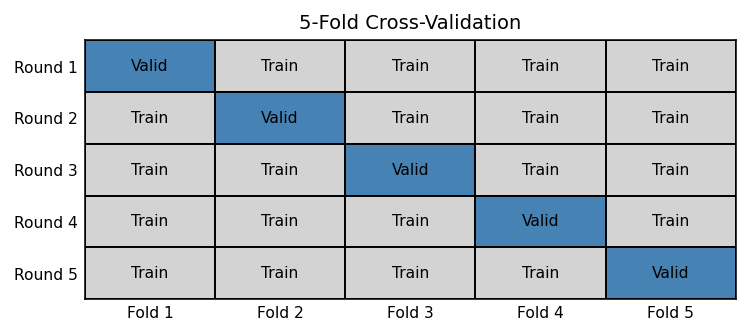
</p>

</div>

<div dir="rtl">

## ۶. <bdi dir="ltr">K-Fold Cross-Validation</bdi>


</div>

In [2]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=0)

for fold_number, (train_index, val_index) in enumerate(kfold.split(X_train), start=1):
    print(f"Fold {fold_number}")
    print("Train size:", len(train_index))
    print("Validation size:", len(val_index))
    print("-" * 30)

Fold 1
Train size: 282
Validation size: 71
------------------------------
Fold 2
Train size: 282
Validation size: 71
------------------------------
Fold 3
Train size: 282
Validation size: 71
------------------------------
Fold 4
Train size: 283
Validation size: 70
------------------------------
Fold 5
Train size: 283
Validation size: 70
------------------------------


<div dir="rtl" class="note-box">

### نکته

در این جلسه برای سادگی فقط از <bdi dir="ltr">KFold</bdi> استفاده می‌کنیم.

</div>

<div dir="rtl">

## ۷. اولین <bdi dir="ltr">Cross-Validation</bdi>

برای مدل‌هایی مثل <bdi dir="ltr">Logistic Regression</bdi> و <bdi dir="ltr">KNN</bdi> بهتر است <bdi dir="ltr">Scaling</bdi> داخل هر Fold انجام شود.

برای همین از <bdi dir="ltr">Pipeline</bdi> استفاده می‌کنیم.

معیار اصلی این جلسه: **<bdi dir="ltr">Macro F1</bdi>** است.

</div>

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, C=1))
])

kfold = KFold(n_splits=5, shuffle=True, random_state=0)

logistic_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="f1_macro"
)

print("Fold scores:", np.round(logistic_scores, 3))
print("Mean Macro F1:", round(logistic_scores.mean(), 3))
print("Std:", round(logistic_scores.std(), 3))

Fold scores: [0.62  0.508 0.627 0.564 0.551]
Mean Macro F1: 0.574
Std: 0.045


In [11]:
logistic_model.fit(
    X_train,
    y_train
)
logistic_model.named_steps["model"].coef_
#logistic_model.named_steps["scaler"].mean_

array([ 48.74787535,   1.48725212,  26.31133144,  94.45509915,
       188.7733711 , 114.87507082,  49.72946176,   4.08175637,
         4.64174363,  91.21529745])

<div dir="rtl">

## ۸. مقایسه‌ی چند مدل با <bdi dir="ltr">Cross-Validation</bdi>

برای ساده‌بودن، مدل‌ها را دانه‌دانه اجرا می‌کنیم.

</div>

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

kfold = KFold(n_splits=5, shuffle=True, random_state=0)

knn_scores = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="f1_macro"
)

print("KNN scores:", np.round(knn_scores, 3))
print("KNN mean:", round(knn_scores.mean(), 3))

KNN scores: [0.491 0.534 0.548 0.579 0.566]
KNN mean: 0.544


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=0)

kfold = KFold(n_splits=5, shuffle=True, random_state=0)

tree_scores = cross_val_score(
    tree_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="f1_macro"
)

print("Decision Tree scores:", np.round(tree_scores, 3))
print("Decision Tree mean:", round(tree_scores.mean(), 3))

Decision Tree scores: [0.522 0.418 0.539 0.442 0.578]
Decision Tree mean: 0.5


In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(n_estimators=100, random_state=0)

kfold = KFold(n_splits=5, shuffle=True, random_state=0)

forest_scores = cross_val_score(
    forest_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="f1_macro"
)

print("Random Forest scores:", np.round(forest_scores, 3))
print("Random Forest mean:", round(forest_scores.mean(), 3))

Random Forest scores: [0.545 0.489 0.545 0.485 0.605]
Random Forest mean: 0.534


<div dir="rtl">

<p>این شکل، مقایسه‌ی اولیه‌ی چند مدل با <bdi dir="ltr">Cross-Validation</bdi> را نشان می‌دهد.</p>

<p align="center">
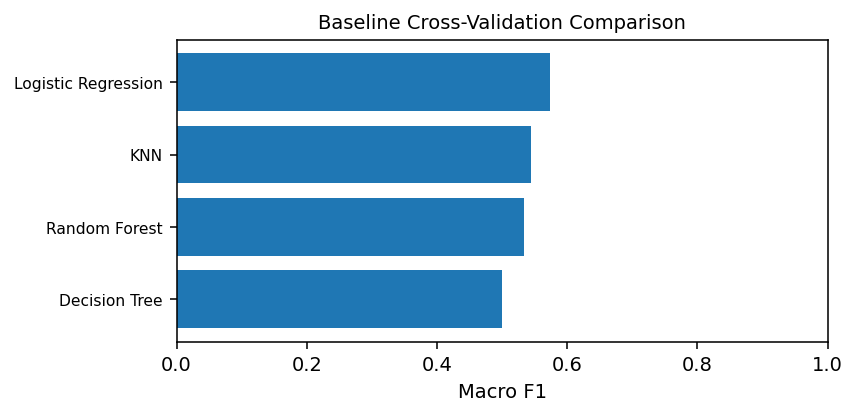
</p>

</div>

<div dir="rtl">

این شکل، مقایسه‌ی اولیه‌ی چند مدل با <bdi dir="ltr">Cross-Validation</bdi> را نشان می‌دهد.

</div>

<div dir="rtl">

<p>شکل زیر ایده‌ی <bdi dir="ltr">Leave-One-Out</bdi> را نشان می‌دهد.</p>

<p align="center">
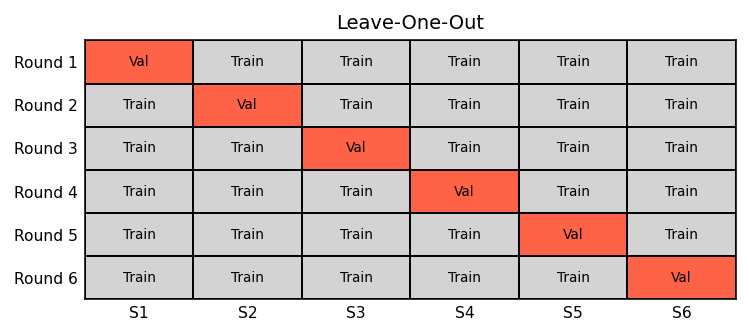
</p>

</div>

<div dir="rtl">

## ۹. <bdi dir="ltr">Leave-One-Out Cross-Validation</bdi>

<bdi dir="ltr">Leave-One-Out</bdi> یک حالت خاص از <bdi dir="ltr">K-Fold</bdi> است:

**<bdi dir="ltr">K = Number of Samples</bdi>**

یعنی در هر مرحله:

- فقط یک نمونه برای <bdi dir="ltr">Validation</bdi>
- بقیه‌ی نمونه‌ها برای <bdi dir="ltr">Training</bdi>

استفاده می‌شوند.

</div>

<div dir="rtl">

شکل زیر ایده‌ی <bdi dir="ltr">Leave-One-Out</bdi> را نشان می‌دهد.

</div>

In [ ]:
from sklearn.model_selection import LeaveOneOut

# We use only a small subset so the code runs quickly.
X_loo = X_train.iloc[:60]
y_loo = y_train.iloc[:60]

loo = LeaveOneOut()

loo_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

loo_scores = cross_val_score(
    loo_model,
    X_loo,
    y_loo,
    cv=loo,
    scoring="accuracy"
)

print("Number of LOOCV folds:", len(loo_scores))
print("LOOCV Accuracy:", round(loo_scores.mean(), 3))

Number of LOOCV folds: 60
LOOCV Accuracy: 0.517


<div dir="rtl" class="note-box">

### نکته

<bdi dir="ltr">Leave-One-Out</bdi> از نظر مفهومی خیلی مهم است، اما روی Datasetهای بزرگ ممکن است کند باشد.

</div>

<div dir="rtl">

## 10. <bdi dir="ltr">Grdid Search</bdi>

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_for_grid = RandomForestClassifier(random_state=0)

rf_grid_params = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 4, 8],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_for_grid,
    param_grid=rf_grid_params,
    cv=kfold,
    scoring="f1_macro",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:")
print(rf_grid.best_params_)
print("Best CV Macro F1:", round(rf_grid.best_score_, 3))

Best parameters:
{'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Macro F1: 0.57


In [ ]:
grid_results = pd.DataFrame(rf_grid.cv_results_)



display(grid_results)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.176559,0.010720,0.013372,0.000477,None,2,50,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.521930,0.502652,0.541296,0.530689,0.615541,0.542422,0.038696,10
1,0.333351,0.008962,0.019717,0.000206,None,2,100,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.545292,0.489337,0.545004,0.485324,0.605185,0.534028,0.044000,15
2,0.508252,0.009726,0.026248,0.000119,None,2,150,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.599562,0.486484,0.516295,0.511500,0.575567,0.537881,0.042493,12
3,0.168519,0.002118,0.012883,0.000106,None,5,50,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.549046,0.531597,0.516686,0.497786,0.590846,0.537192,0.031698,13
4,0.332472,0.012351,0.020717,0.001386,None,5,100,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.553363,0.512818,0.481540,0.522563,0.603917,0.534840,0.041452,14
5,0.494002,0.009587,0.026395,0.000444,None,5,150,"{'max_depth': None, 'min_samples_split': 5, 'n...",0.560155,0.491040,0.510445,0.537086,0.607352,0.541216,0.040532,11
6,0.157304,0.009700,0.012839,0.000238,4,2,50,"{'max_depth': 4, 'min_samples_split': 2, 'n_es...",0.592076,0.507265,0.551304,0.524217,0.675095,0.569991,0.059856,2
7,0.295900,0.003311,0.019051,0.000143,4,2,100,"{'max_depth': 4, 'min_samples_split': 2, 'n_es...",0.567137,0.465054,0.537562,0.508570,0.652924,0.546249,0.063093,8
8,0.723851,0.107227,0.045437,0.009608,4,2,150,"{'max_depth': 4, 'min_samples_split': 2, 'n_es...",0.567137,0.490598,0.540404,0.505698,0.653879,0.551543,0.057717,5
9,0.289014,0.033014,0.023096,0.006234,4,5,50,"{'max_depth': 4, 'min_samples_split': 5, 'n_es...",0.592076,0.503780,0.564834,0.508570,0.653879,0.564628,0.055793,3


<div dir="rtl">

## ۱۱. <bdi dir="ltr">Random Search</bdi>

در <bdi dir="ltr">Random Search</bdi> همه‌ی ترکیب‌ها بررسی نمی‌شوند.

فقط چند ترکیب به‌صورت تصادفی انتخاب و امتحان می‌شوند.

باز هم از <bdi dir="ltr">Random Forest</bdi> استفاده می‌کنیم.

</div>

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_for_random = RandomForestClassifier(random_state=0)

rf_random_params = {
    "n_estimators": [50, 100, 150, 200, 250],
    "max_depth": [None, 3, 5, 7, 9],
    "min_samples_split": [2, 4, 6, 8],
    "min_samples_leaf": [1, 2, 3, 4]
}

rf_random = RandomizedSearchCV(
    estimator=rf_for_random,
    param_distributions=rf_random_params,
    n_iter=12,
    cv=kfold,
    scoring="f1_macro",
    random_state=0,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best parameters:")
print(rf_random.best_params_)
print("Best CV Macro F1:", round(rf_random.best_score_, 3))

Best parameters:
{'n_estimators': 100, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_depth': 7}
Best CV Macro F1: 0.557


In [ ]:
random_results = pd.DataFrame(rf_random.cv_results_)

random_table = random_results[[
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "mean_test_score"
]].sort_values("mean_test_score", ascending=False)

display(random_table.head(10).round(3))

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score
4,100,7,4,1,0.557
3,100,5,8,2,0.556
0,150,3,6,3,0.554
7,100,7,2,2,0.554
1,250,7,4,4,0.554
6,50,3,8,4,0.554
8,100,3,2,4,0.554
5,50,None,2,4,0.548
10,150,None,8,2,0.547
2,100,9,2,2,0.541


<div dir="rtl">

## ۱۲. <bdi dir="ltr">Optuna</bdi>

ایده‌ی ساده‌ی <bdi dir="ltr">Optuna</bdi> این است:

1. چند مقدار برای <bdi dir="ltr">Hyperparameter</bdi> پیشنهاد می‌شود؛
2. مدل با آن تنظیمات ارزیابی می‌شود؛
3. امتیاز برمی‌گردد؛
4. Trialهای بعدی با توجه به نتایج قبلی بهتر می‌شوند.

اینجا هم برای سادگی از <bdi dir="ltr">Random Forest</bdi> استفاده می‌کنیم.

</div>

In [ ]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.8 MB/s eta 0:00:00


In [ ]:
# If Optuna is not installed in a new environment, run this once:
# !pip install -q optuna

import optuna


def objective(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 200),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 8),
        random_state=0
    )

#learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1),

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring="f1_macro"
    )

    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=12)

print("Best parameters:")
print(study.best_params)
print("Best CV Macro F1:", round(study.best_value, 3))

[I 2026-09-18 23:14:54,301] A new study created in memory with name: no-name-ea512a31-add6-4adf-acb0-370868c1aad2
[I 2026-09-18 23:14:59,438] Trial 0 finished with value: 0.5674462676301263 and parameters: {'n_estimators': 156, 'max_depth': 5, 'min_samples_split': 3}. Best is trial 0 with value: 0.5674462676301263.
[I 2026-09-18 23:15:02,575] Trial 1 finished with value: 0.5522032429826809 and parameters: {'n_estimators': 132, 'max_depth': 6, 'min_samples_split': 4}. Best is trial 0 with value: 0.5674462676301263.
[I 2026-09-18 23:15:04,768] Trial 2 finished with value: 0.5327504546403307 and parameters: {'n_estimators': 181, 'max_depth': 7, 'min_samples_split': 3}. Best is trial 0 with value: 0.5674462676301263.
[I 2026-09-18 23:15:06,317] Trial 3 finished with value: 0.5504901877686013 and parameters: {'n_estimators': 151, 'max_depth': 8, 'min_samples_split': 5}. Best is trial 0 with value: 0.5674462676301263.
[I 2026-09-18 23:15:07,745] Trial 4 finished with value: 0.555391535831522

Best parameters:
{'n_estimators': 156, 'max_depth': 5, 'min_samples_split': 3}
Best CV Macro F1: 0.567


In [ ]:
optuna_results = study.trials_dataframe(attrs=("number", "value", "params"))
print(optuna_results.sort_values("value", ascending=False).head(10).round(3))

    number  value  params_max_depth  params_min_samples_split  \
0        0  0.567                 5                         3   
4        4  0.555                 7                         4   
5        5  0.554                 5                         4   
1        1  0.552                 6                         4   
10      10  0.551                 4                         6   
8        8  0.551                 8                         3   
3        3  0.550                 8                         5   
6        6  0.550                 3                         3   
7        7  0.546                 6                         2   
11      11  0.537                10                         2   

    params_n_estimators  
0                   156  
4                   138  
5                   199  
1                   132  
10                   85  
8                   121  
3                   151  
6                   127  
7                   139  
11                  155 

<div dir="rtl">

## ۱۴. جلوگیری از <bdi dir="ltr">Data Leakage</bdi> هنگام انتخاب مدل

یکی از مهم‌ترین نکات این جلسه این است:

> هر چیزی که از داده «یاد می‌گیرد» باید داخل فرآیند <bdi dir="ltr">Cross-Validation</bdi> قرار بگیرد.

مثلاً <bdi dir="ltr">StandardScaler</bdi> میانگین و انحراف معیار را از داده یاد می‌گیرد.

اگر قبل از <bdi dir="ltr">Cross-Validation</bdi> روی کل Training Data آن را <bdi dir="ltr">fit</bdi> کنیم، اطلاعات Foldهای دیگر وارد Validation می‌شود.

</div>

<div dir="rtl" class="warning-box">

### الگوی اشتباه

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

cross_val_score(model, X_scaled, y_train, cv=kfold)
```

### الگوی درست

<bdi dir="ltr">Scaler</bdi> و مدل را داخل یک <bdi dir="ltr">Pipeline</bdi> قرار می‌دهیم.

</div>

In [ ]:
safe_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

safe_scores = cross_val_score(
    safe_pipeline,
    X_train,
    y_train,
    cv=kfold,
    scoring="f1_macro"
)

print("Leakage-safe CV Macro F1:", round(safe_scores.mean(), 3))

Leakage-safe CV Macro F1: 0.568


<div dir="rtl">

## ۱۵. مقایسه‌ی مدل‌های تنظیم‌شده

تا اینجا سه نتیجه‌ی مهم داریم:

- <bdi dir="ltr">Random Forest + Grid Search</bdi>
- <bdi dir="ltr">Random Forest + Random Search</bdi>
- <bdi dir="ltr">Random Forest + Optuna</bdi>

حالا فقط امتیازهای <bdi dir="ltr">Cross-Validation</bdi> را مقایسه می‌کنیم.

</div>

In [ ]:
tuned_results = pd.DataFrame({
    "Method": ["Grid Search", "Random Search", "Optuna"],
    "Best CV Macro F1": [
        rf_grid.best_score_,
        rf_random.best_score_,
        study.best_value
    ]
}).sort_values("Best CV Macro F1", ascending=False)

print(tuned_results.round(3))

          Method  Best CV Macro F1
0    Grid Search             0.570
2         Optuna             0.567
1  Random Search             0.557


<div dir="rtl">

## ۱۶. <bdi dir="ltr">Final Model Selection</bdi>

مدل نهایی را بر اساس بهترین نتیجه‌ی <bdi dir="ltr">Cross-Validation</bdi> انتخاب می‌کنیم.

بعد:

1. همان مدل را روی تمام <bdi dir="ltr">Training Data</bdi> دوباره آموزش می‌دهیم؛
2. فقط یک بار روی <bdi dir="ltr">Test Set</bdi> ارزیابی می‌کنیم.

</div>

In [ ]:
best_method = tuned_results.iloc[0]["Method"]

if best_method == "Grid Search":
    final_model = rf_grid.best_estimator_
elif best_method == "Random Search":
    final_model = rf_random.best_estimator_
else:
    final_model = RandomForestClassifier(**study.best_params, random_state=0)

final_model.fit(X_train, y_train)

print("Selected method:", best_method)
print("Final model:", final_model)

Selected method: Grid Search
Final model: RandomForestClassifier(max_depth=8, min_samples_split=5, random_state=0)


<div dir="rtl" class="note-box">

### اینجا چرا انتخاب درست است؟

مدل نهایی با دیدن نتیجه‌ی <bdi dir="ltr">Test Set</bdi> انتخاب نشده است.

انتخاب فقط بر اساس:

- <bdi dir="ltr">Training Data</bdi>
- <bdi dir="ltr">Cross-Validation</bdi>
- امتیاز <bdi dir="ltr">Macro F1</bdi>

انجام شده است.

</div>

<div dir="rtl">

## ۱۷. ارزیابی نهایی روی <bdi dir="ltr">Test Set</bdi>

این اولین بار است که نتیجه‌ی Test را می‌بینیم.

بعد از این مرحله، دیگر نباید Hyperparameterها را براساس نتیجه‌ی Test تغییر دهیم.

</div>

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

final_prediction = final_model.predict(X_test)

final_metrics = pd.DataFrame([{
    "Accuracy": accuracy_score(y_test, final_prediction),
    "Macro Precision": precision_score(y_test, final_prediction, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_test, final_prediction, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test, final_prediction, average="macro", zero_division=0)
}])

print(final_metrics.round(3))

   Accuracy  Macro Precision  Macro Recall  Macro F1
0     0.517            0.519         0.557     0.526


In [ ]:
class_names = ["Low", "Medium", "High"]
cm = confusion_matrix(y_test, final_prediction, labels=class_names)

cm_table = pd.DataFrame(
    cm,
    index=["Actual Low", "Actual Medium", "Actual High"],
    columns=["Predicted Low", "Predicted Medium", "Predicted High"]
)

print(cm_table)
print("\nClassification Report:")
print(classification_report(y_test, final_prediction, labels=class_names, zero_division=0))

               Predicted Low  Predicted Medium  Predicted High
Actual Low                16                 4               2
Actual Medium             11                15              15
Actual High                2                 9              15

Classification Report:
              precision    recall  f1-score   support

         Low       0.55      0.73      0.63        22
      Medium       0.54      0.37      0.43        41
        High       0.47      0.58      0.52        26

    accuracy                           0.52        89
   macro avg       0.52      0.56      0.53        89
weighted avg       0.52      0.52      0.51        89



<div dir="rtl">

## ۱۸. Workflow استاندارد انتخاب مدل

<div class="flow-box">
<bdi dir="ltr">
1. Split Final Test Set<br>
↓<br>
2. Choose a CV Strategy<br>
↓<br>
3. Compare Simple Models<br>
↓<br>
4. Tune Hyperparameters<br>
↓<br>
5. Compare CV Results<br>
↓<br>
6. Select Final Model<br>
↓<br>
7. Refit on Full Training Data<br>
↓<br>
8. Evaluate on Test Once
</bdi>
</div>

</div>

<div dir="rtl" style="font-size: 16px; line-height: 2; text-align: right;">

<h2>۱۹. Quiz کوتاه</h2>

<h3>سؤال ۱</h3>
<p>
کدام مورد یک
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">Hyperparameter</span>
است؟
</p>

<p>
<span dir="ltr">A.</span> ضرایب یادگرفته‌شده‌ی مدل<br>

<span dir="ltr">B.</span>
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">n_estimators</span>
در
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">Random Forest</span>
<br>

<span dir="ltr">C.</span>
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">Prediction</span>
نهایی
</p>


<h3>سؤال ۲</h3>
<p>
در
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">
5-Fold Cross-Validation
</span>
چند بار مدل آموزش داده می‌شود؟
</p>

<p>
<span dir="ltr">A.</span> ۱ بار<br>
<span dir="ltr">B.</span> ۵ بار<br>
<span dir="ltr">C.</span> به تعداد
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">Features</span>
</p>


<h3>سؤال ۳</h3>
<p>
در
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">
Leave-One-Out
</span>
در هر مرحله چند نمونه برای
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">
Validation
</span>
استفاده می‌شود؟
</p>

<p>
<span dir="ltr">A.</span> یک نمونه<br>
<span dir="ltr">B.</span> دو نمونه<br>
<span dir="ltr">C.</span> نصف داده
</p>


<h3>سؤال ۴</h3>
<p>
فرق اصلی
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">Grid Search</span>
و
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">Random Search</span>
چیست؟
</p>

<p>
<span dir="ltr">A.</span>
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">Grid</span>
همه‌ی ترکیب‌ها را چک می‌کند ولی
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">Random</span>
فقط چند ترکیب را
<br>

<span dir="ltr">B.</span>
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">Random</span>
همیشه بهتر است
<br>

<span dir="ltr">C.</span> هیچ تفاوتی ندارند
</p>


<h3>سؤال ۵</h3>
<p>
چرا از
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">
Pipeline
</span>
استفاده می‌کنیم؟
</p>

<p>
<span dir="ltr">A.</span>
برای جلوگیری از
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">
Data Leakage
</span>
<br>

<span dir="ltr">B.</span> فقط برای زیباترشدن کد<br>

<span dir="ltr">C.</span> فقط برای
<span dir="ltr" style="font-family: Arial, 'DejaVu Sans', sans-serif;">
Dataset
</span>
های بزرگ
</p>

</div>

<div dir="rtl" style="font-family: Tahoma, Arial, 'DejaVu Sans', sans-serif; font-size: 16px; line-height: 2; text-align: right;">
<details>
<summary><b>پاسخ Quiz — برای مشاهده کلیک کنید</b></summary>
<p><b>۱. B —</b> <bdi dir="ltr">n_estimators</bdi></p>
<p><b>۲. B —</b> ۵ بار</p>
<p><b>۳. A —</b> یک نمونه</p>
<p><b>۴. A —</b> Grid همه‌ی ترکیب‌ها را بررسی می‌کند، Random فقط چند ترکیب را.</p>
<p><b>۵. A —</b> برای جلوگیری از <bdi dir="ltr">Data Leakage</bdi></p>
</details>
</div>

<div dir="rtl">

## ۲۰. تمرین ۱ — تغییر تعداد Foldها

کد <bdi dir="ltr">Cross-Validation</bdi> را با مقادیر زیر اجرا کنید:

- <bdi dir="ltr">3 folds</bdi>
- <bdi dir="ltr">5 folds</bdi>
- <bdi dir="ltr">10 folds</bdi>

برای هر حالت:

- <bdi dir="ltr">Mean Macro F1</bdi>
- <bdi dir="ltr">Standard Deviation</bdi>

را گزارش کنید.

</div>

In [ ]:
n_splits = 5
exercise_kfold = KFold(n_splits=n_splits, shuffle=True, random_state=0)

exercise_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=exercise_kfold,
    scoring="f1_macro"
)

print("Number of folds:", n_splits)
print("Mean Macro F1:", round(exercise_scores.mean(), 3))
print("Std:", round(exercise_scores.std(), 3))

Number of folds: 5
Mean Macro F1: 0.574
Std: 0.045


<div dir="rtl">

## ۲۱. تمرین ۲ — طراحی یک <bdi dir="ltr">Grid Search</bdi>

برای <bdi dir="ltr">Random Forest</bdi> یک <bdi dir="ltr">Grid Search</bdi> بسازید و مقادیر زیر را امتحان کنید:

- <bdi dir="ltr">n_estimators = [50, 100, 150]</bdi>
- <bdi dir="ltr">max_depth = [None, 4, 8]</bdi>

### سؤال

بهترین ترکیب چیست؟

</div>

In [ ]:
exercise_model = RandomForestClassifier(random_state=0)
exercise_params = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 4, 8]
}

exercise_grid = GridSearchCV(
    estimator=exercise_model,
    param_grid=exercise_params,
    cv=kfold,
    scoring="f1_macro",
    n_jobs=-1
)

exercise_grid.fit(X_train, y_train)

print("Best parameters:", exercise_grid.best_params_)
print("Best CV Macro F1:", round(exercise_grid.best_score_, 3))

Best parameters: {'max_depth': 4, 'n_estimators': 50}
Best CV Macro F1: 0.57


<div dir="rtl">

## ۲۲. تمرین ۳ — پیدا کردن <bdi dir="ltr">Data Leakage</bdi>

فرض کنید یک نفر این کد را نوشته است:

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

cross_val_score(model, X_train_scaled, y_train, cv=kfold)
```

### سؤال‌ها

1. مشکل این Workflow چیست؟
2. چرا ممکن است Validation Score خوش‌بینانه شود؟
3. چطور با <bdi dir="ltr">Pipeline</bdi> آن را اصلاح می‌کنید؟

</div>

<div dir="rtl">

# جمع‌بندی جلسه ۶

در این جلسه یاد گرفتیم که انتخاب مدل فقط به معنی امتحان‌کردن چند الگوریتم نیست.

مراحل اصلی ما این‌ها بودند:

- <bdi dir="ltr">Hyperparameters</bdi>
- <bdi dir="ltr">K-Fold Cross-Validation</bdi>
- <bdi dir="ltr">Leave-One-Out</bdi>
- <bdi dir="ltr">Grid Search</bdi>
- <bdi dir="ltr">Random Search</bdi>
- <bdi dir="ltr">Optuna</bdi>
- جلوگیری از <bdi dir="ltr">Data Leakage</bdi>
- <bdi dir="ltr">Final Model Selection</bdi>

> پیام اصلی جلسه:  
> **مدل را با Cross-Validation انتخاب کنید، Hyperparameterها را فقط روی Training Data تنظیم کنید، و Test Set را تا پایان دست‌نخورده نگه دارید.**

</div>